<a href="https://colab.research.google.com/github/DavidMuthama/Strathmore/blob/main/Data_cleaning_professional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.cluster import *
from sklearn.preprocessing import *
from sklearn.metrics import *
from sklearn.model_selection import *
from sklearn.ensemble import *
from sklearn.linear_model import *
from sklearn.tree import *
from sklearn.neighbors import *
from sklearn.svm import *
import kagglehub as kh

In [3]:
df=pd.read_csv('/content/ihm_48_hours.csv')
df.isna().sum()

,0
Capillary refill rate,294576
Diastolic blood pressure,3968
Fraction inspired oxygen,212448
Glascow coma scale eye opening,26722
Glascow coma scale motor response,3934
Glascow coma scale total,116496
Glascow coma scale verbal response,4028
Glucose,214
Heart Rate,0
Height,245088


In [4]:
new_df=df.drop(columns=['Capillary refill rate','Fraction inspired oxygen','Height'])
new_df.tail()

,Diastolic blood pressure,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,Patient_id,target
300907,59.0,4 Spontaneously,6 Obeys Commands,15.0,5 Oriented,105.0,129.0,89.0,98.0,14.0,110.0,38.277802,NaN,7.36,11623,0
300908,61.0,4 Spontaneously,NaN,15.0,5 Oriented,105.0,108.0,80.0,98.0,15.0,116.0,37.444445,NaN,7.36,11623,0
300909,61.0,4 Spontaneously,6 Obeys Commands,15.0,5 Oriented,100.0,108.0,80.0,98.0,15.0,116.0,37.444445,NaN,7.36,11623,0
300910,52.0,4 Spontaneously,6 Obeys Commands,15.0,5 Oriented,100.0,108.0,80.0,98.0,16.0,101.0,37.444445,NaN,7.36,11623,0
300911,53.0,4 Spontaneously,6 Obeys Commands,15.0,5 Oriented,100.0,108.0,80.0,99.0,19.0,105.0,37.444445,NaN,7.36,11623,0


In [5]:
new_df['Glascow coma scale eye opening'].unique()

array(['Spontaneously', '1 No Response', '4 Spontaneously', '2 To pain',
       '3 To speech', nan, 'To Pain', 'To Speech'], dtype=object)

In [6]:
new_df['Weight'].unique()

array([ 83.5       ,  67.69999695,  78.        , ..., 122.80000305,
        54.7       , 103.2828984 ])

In [7]:
new_df['Glascow coma scale eye opening'].fillna('No Response',inplace=True)
new_df['Glascow coma scale eye opening'].replace('1 No Response','No Response',inplace=True)
new_df['Glascow coma scale eye opening'].replace('2 To pain','To Pain',inplace=True)
new_df['Glascow coma scale eye opening'].replace('3 To speech','To Speech',inplace=True)
new_df['Glascow coma scale eye opening'].replace('4 Spontaneously','Spontaneously',inplace=True)

new_df['Glascow coma scale motor response'].fillna('No response',inplace=True)
new_df['Glascow coma scale motor response'].replace('1 No Response','No response',inplace=True)
new_df['Glascow coma scale motor response'].replace('2 Abnorm extensn','Abnormal extension',inplace=True)
new_df['Glascow coma scale motor response'].replace('3 Abnorm flexion','Abnormal Flexion',inplace=True)
new_df['Glascow coma scale motor response'].replace('4 Flex-withdraws','Flex-withdraws',inplace=True)
new_df['Glascow coma scale motor response'].replace('5 Localizes Pain','Localizes Pain',inplace=True)
new_df['Glascow coma scale motor response'].replace('6 Obeys Commands','Obeys Commands',inplace=True)

new_df['Glascow coma scale verbal response'].fillna('No response',inplace=True)
new_df['Glascow coma scale verbal response'].replace('1 No Response','No Response',inplace=True)
new_df['Glascow coma scale verbal response'].replace('No Response-ETT','No Response',inplace=True)
new_df['Glascow coma scale verbal response'].replace('2 Incomp sounds','Incomprehensible sounds',inplace=True)
new_df['Glascow coma scale verbal response'].replace('3 Inapprop words','Inappropriate Words',inplace=True)
new_df['Glascow coma scale verbal response'].replace('4 Confused','Confused',inplace=True)
new_df['Glascow coma scale verbal response'].replace('5 Oriented','Oriented',inplace=True)

<ipython-input-7-d188e590fdc0>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df['Glascow coma scale eye opening'].fillna('No Response',inplace=True)
<ipython-input-7-d188e590fdc0>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [8]:
new_df.tail()

,Diastolic blood pressure,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,Patient_id,target
300907,59.0,Spontaneously,Obeys Commands,15.0,Oriented,105.0,129.0,89.0,98.0,14.0,110.0,38.277802,NaN,7.36,11623,0
300908,61.0,Spontaneously,No response,15.0,Oriented,105.0,108.0,80.0,98.0,15.0,116.0,37.444445,NaN,7.36,11623,0
300909,61.0,Spontaneously,Obeys Commands,15.0,Oriented,100.0,108.0,80.0,98.0,15.0,116.0,37.444445,NaN,7.36,11623,0
300910,52.0,Spontaneously,Obeys Commands,15.0,Oriented,100.0,108.0,80.0,98.0,16.0,101.0,37.444445,NaN,7.36,11623,0
300911,53.0,Spontaneously,Obeys Commands,15.0,Oriented,100.0,108.0,80.0,99.0,19.0,105.0,37.444445,NaN,7.36,11623,0


In [9]:
categorical_df = new_df.select_dtypes(include=['object']).drop(columns=['Patient_id'])
categorical_df.dropna(subset=categorical_df.columns)
# categorical_df.head()
# categorical_df.isna().sum()
categorical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300912 entries, 0 to 300911
Data columns (total 3 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Glascow coma scale eye opening      300912 non-null  object
 1   Glascow coma scale motor response   300912 non-null  object
 2   Glascow coma scale verbal response  300912 non-null  object
dtypes: object(3)
memory usage: 6.9+ MB


In [26]:
numerical_df=new_df.select_dtypes(include=['int64','float64'])
# numerical_df.head()
numerical_df.describe()

,Diastolic blood pressure,Glascow coma scale total,Glucose,Heart Rate,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,target
count,296944.000000,184416.000000,300698.000000,300912.000000,296984.00000,300912.000000,300864.000000,300912.000000,298848.000000,221040.000000,230614.000000,300912.000000
mean,62.541099,10.818123,130.628329,79.447793,78.79108,95.343460,18.731265,119.694213,36.832834,82.969018,5.573617,0.142128
std,341.559624,4.334923,84.171126,32.145920,29.52986,2529.203751,6.884248,23.396042,1.000075,26.765857,5.963634,0.349182
min,0.000000,3.000000,-19.999974,-19.999623,-34.00000,-19.999687,0.000000,0.000000,0.000000,0.000000,-19.999706,0.000000
25%,51.000000,8.000000,101.000000,70.000000,68.00000,95.000000,15.000000,103.000000,36.277802,66.600000,7.310000,0.000000
50%,59.000000,11.000000,126.000000,84.000000,77.00000,98.000000,18.000000,117.000000,36.833333,79.099998,7.370000,0.000000
75%,69.000000,15.000000,158.000000,97.000000,88.00000,100.000000,22.000000,134.000000,37.388889,94.699997,7.420000,0.000000
max,100105.010000,15.000000,9999.000000,941.000000,9381.00000,981023.000000,1211.000000,295.000000,73.760002,931.224376,99.000000,1.000000


In [15]:
#mean imputation
# numerical_df.isna().sum()
# for x in numerical_df.columns:
#   numerical_df[x].fillna(numerical_df[x].mean(),inplace=True)
# numerical_df.isna().sum()

<ipython-input-15-99f5b0dbde3f>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  numerical_df[x].fillna(numerical_df[x].mean(),inplace=True)


In [27]:
def bootstrap_imputation(df, numerical_columns):
    df_imputed = df.copy()

    for column in numerical_columns:
        # Get non-missing values
        valid_values = df[column].dropna().values
        # Get indices of missing values
        missing_indices = df[column].isnull()

        # Skip if no missing values
        if missing_indices.sum() == 0:
            print(f"Column: {column} - No missing values to impute\n")
            continue

        # Check if there are valid values to sample from
        if len(valid_values) == 0:
            print(f"Column: {column} - All values are missing, using mean imputation instead")
            # Fallback to mean imputation or another method
            df_imputed[column] = df[column].fillna(df[column].mean())
            continue

        try:
            # Generate random samples from non-missing values
            random_samples = np.random.choice(
                valid_values,
                size=missing_indices.sum(),
                replace=True
            )

            # Perform imputation
            df_imputed.loc[missing_indices, column] = random_samples

            # Print imputation summary only if we have valid samples
            if len(random_samples) > 0:
                print(f"Column: {column}")
                print(f"Missing values filled: {missing_indices.sum()}")
                print(f"Range of imputed values: [{random_samples.min():.2f}, {random_samples.max():.2f}]\n")

        except Exception as e:
            print(f"Error processing column {column}: {str(e)}")
            # Fallback to mean imputation
            df_imputed[column] = df[column].fillna(df[column].mean())

    return df_imputed


In [31]:
conf_numerical_df = bootstrap_imputation(numerical_df, numerical_df.columns)

Column: Diastolic blood pressure
Missing values filled: 3968
Range of imputed values: [0.00, 7272.00]

Column: Glascow coma scale total
Missing values filled: 116496
Range of imputed values: [3.00, 15.00]

Column: Glucose
Missing values filled: 214
Range of imputed values: [-15.78, 548.00]

Column: Heart Rate - No missing values to impute

Column: Mean blood pressure
Missing values filled: 3928
Range of imputed values: [-5.00, 292.00]

Column: Oxygen saturation - No missing values to impute

Column: Respiratory rate
Missing values filled: 48
Range of imputed values: [11.00, 36.00]

Column: Systolic blood pressure - No missing values to impute

Column: Temperature
Missing values filled: 2064
Range of imputed values: [0.00, 40.44]

Column: Weight
Missing values filled: 79872
Range of imputed values: [0.00, 931.22]

Column: pH
Missing values filled: 70298
Range of imputed values: [-20.00, 99.00]

Column: target - No missing values to impute



In [32]:
conf_numerical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300912 entries, 0 to 300911
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Diastolic blood pressure  300912 non-null  float64
 1   Glascow coma scale total  300912 non-null  float64
 2   Glucose                   300912 non-null  float64
 3   Heart Rate                300912 non-null  float64
 4   Mean blood pressure       300912 non-null  float64
 5   Oxygen saturation         300912 non-null  float64
 6   Respiratory rate          300912 non-null  float64
 7   Systolic blood pressure   300912 non-null  float64
 8   Temperature               300912 non-null  float64
 9   Weight                    300912 non-null  float64
 10  pH                        300912 non-null  float64
 11  target                    300912 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 27.5 MB


In [35]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=10, min_samples=10) # Adjust eps and min_samples as needed
dbscan.fit(conf_numerical_df)

labels = dbscan.labels_
outliers = conf_numerical_df[labels == -1] # -1 indicates noise/outliers

In [59]:
outlier_indices = outliers.index

# Remove rows from conf_numerical_df based on outlier indices
conf_numerical_df = conf_numerical_df.drop(index=outlier_indices)

# Print the shape of the dataframe after removing outliers
print(conf_numerical_df.shape)

(97994, 12)


In [65]:
conf_numerical_df.describe()

,Diastolic blood pressure,Glascow coma scale total,Glucose,Heart Rate,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,target
count,97994.000000,97994.000000,97994.000000,97994.000000,97994.000000,97994.000000,97994.000000,97994.000000,97994.000000,97994.000000,97994.000000,97994.000000
mean,58.093526,11.076321,118.767569,82.574856,75.102074,97.855634,17.570310,113.837898,36.833887,79.061216,7.353749,0.107864
std,9.753092,4.187093,39.035362,16.753499,10.574717,2.266159,4.657956,15.937714,0.803757,15.847134,0.491710,0.310210
min,24.000000,3.000000,-19.996307,-19.961605,43.000000,80.000000,0.000000,72.000000,29.444444,31.800000,-8.848708,0.000000
25%,51.000000,8.000000,103.000000,74.000000,67.000000,96.000000,14.000000,102.000000,36.299999,67.800000,7.340000,0.000000
50%,57.000000,11.000000,121.000000,83.000000,74.000000,98.000000,17.000000,112.000000,36.833335,77.900000,7.390000,0.000000
75%,65.000000,15.000000,140.000000,92.000000,82.000000,100.000000,20.000000,124.000000,37.333333,89.500000,7.430000,0.000000
max,100.000000,15.000000,472.000000,141.000000,126.000000,100.000000,43.000000,197.000000,41.611112,198.000000,7.690000,1.000000


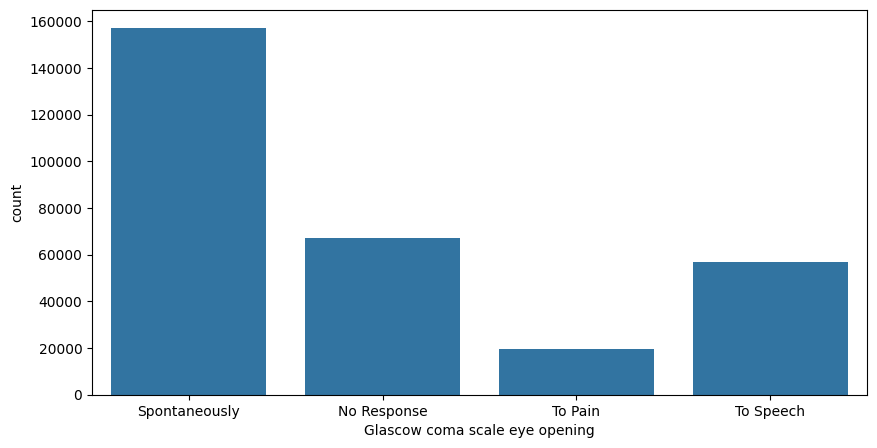

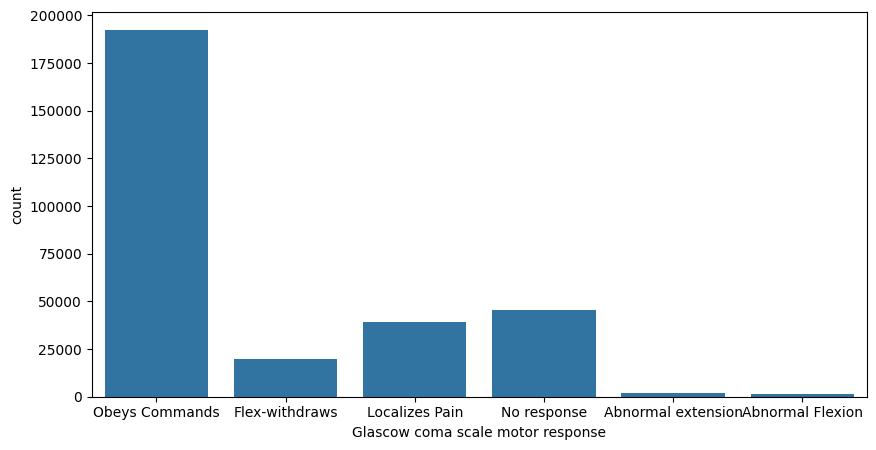

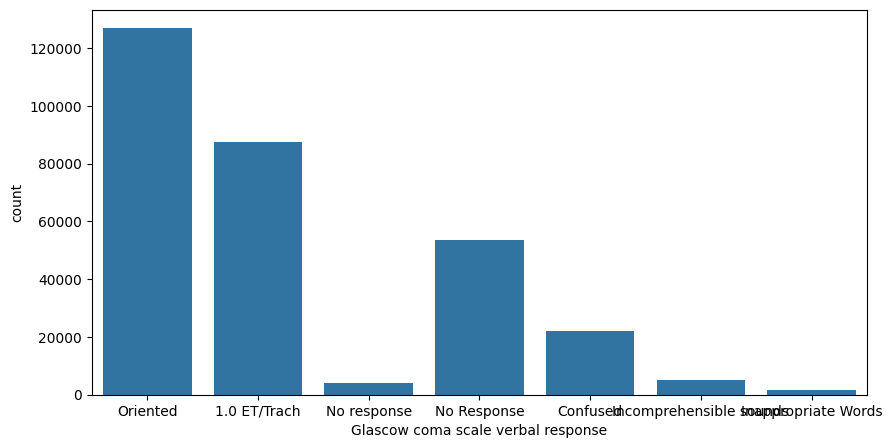

In [66]:
for x in categorical_df.columns:
  plt.figure(figsize=(10,5))
  sns.countplot(data=categorical_df,x=x)